# BiPlane Challenge

In [28]:
try:
    import mat73
except ImportError:
    pass

from pathlib import Path

import copy
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

In [ ]:
path = "~/jobs/deploy/decode"
path = Path(path).expanduser()
import sys

sys.path.insert(0, str(path))

In [ ]:
import decode
import decode.evaluation.optimize
from decode.neuralfitter.train import setup_cfg
import decode.neuralfitter.inference.functional as infer_func
print(decode.__file__)


%config InlineBackend.figure_format='retina'

In [ ]:
path_out = "/mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge"
path_out = Path(path_out)

path_smap = "/mnt/t1ries/decode/fit/biplane_challenge/"
path_smap = Path(path_smap)

path_scen = path_out / "scen_out.pkl"

In [83]:
scen_out = pd.read_pickle(path_scen)
scen_out

dataset  \
snr  density type  algorithm              
low  low     train DECODE     MT0_N2_LD   
             test  DECODE     MT3_N2_LD   
     high    train DECODE     MT0_N2_HD   
             test  DECODE     MT4_N2_HD   
high low     train DECODE     MT0_N1_LD   
             test  DECODE     MT1_N1_LD   
     high    train DECODE     MT0_N1_HD   
             test  DECODE     MT2_N1_HD   

                                                                      path_data  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                                     path_frame  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT3_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT4_N...   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT1_N...   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE     /home/riesgroup/decode_scratch/challenge/MT2_N...   

                                                                        path_em  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
high low     train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   
     high    train DECODE     /home/riesgroup/decode_scratch/challenge/MT0_N...   
             test  DECODE                                                  None   

                                                                     path_model  \
snr  density type  algorithm                                                      
low  low     train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
high low     train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
     high    train DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   
             test  DECODE     /home/riesgroup/decode_storage/dev/lucas/train...   

                                                                    path_em_out  
snr  density type  algorithm                                                     
low  low     train DECODE     /mnt/t1ries/users/Lucas/Manuscripts/plex/raw/b...  
             test  DECODE     /

In [ ]:
scen = pd.DataFrame(index=scen_out.index)
scen["em"] = None
scen["em_out"] = None

# load emitters, gt and decode
for i, row in scen.join(scen_out).iterrows():
    if row["path_em_out"] is not None:
        scen.at[i, "em_out"] = decode.EmitterSet.load(row["path_em_out"])

    if row["path_em"] is None:
        continue

    em, *_ = decode.io.emitter.load_challenge(row["path_data"] / "activations.csv")
    em = decode.EmitterSet(**em, xy_unit="nm", px_size=(100., 100.))
    scen.at[i, "em"] = em

scen

In [ ]:
# convert to challenge standard
for i, r in scen.iterrows():
    if r["em_out"] is None:
        continue

    em = r["em_out"].clone()
    match i[-1]:
        case "DECODE":
            em = decode.evaluation.challenge.convert.decode_to_chall(em)
            em.xyz_nm -= torch.tensor([ 5.45,  5.45, -10.45])
            em.xyz_nm[:, 2] *= 0.98
            em.phot /= 0.684
        case "SMAP":
            # em.xyz_px = em.xyz_px - torch.tensor([65., 0., 0.])
            em.frame_ix = em.frame_ix + 1
        case _:
            raise ValueError
    scen.at[i, "em_out"] = em

scen

In [ ]:
# scen_smap = pd.DataFrame(index=scen.index)
# scen_smap["algorithm"] = "SMAP"
# scen_smap.set_index("algorithm", append=True, inplace=True)
# scen_smap["path_em"] = None
# scen_smap["em_out"] = None


# scen_smap.loc[("high", "low", "train"), "path_em"] = path_smap / "MT0_N1_LD"/ "JRTEST_sequence-MT0.N1.LD-BP-Exp-as-stack_sml.mat" #"sequence-MT0.N1.LD-BP-Exp-as-stack_beads10nm_2_sml.mat"

# for i, r in scen_smap.iterrows():
#     if r["path_em"] is None:
#         continue

#     em, *_ = decode.io.emitter.load_smap(r["path_em"], return_raw=False)
#     em = decode.EmitterSet(**em, xy_unit="nm", px_size=(100., 100.))
#     scen_smap.at[i, "em_out"] = em

# scen_smap["em"] = scen["em"]
# scen_smap

In [ ]:
matcher = decode.evaluation.match_emittersets.GreedyHungarianMatching(
    # match_dims=2, dist_ax=500., dist_lat=250.,
    match_dims=2, dist_ax=None, dist_lat=450.
)
ev = decode.evaluation.evaluation.SMLMEvaluation()

# Filter Tuning

In [ ]:
# challenge fov filtering
xy_extent = (2.5, 60.5)
filter_fov = decode.emitter.process.EmitterFilterFoV(xy_extent, xy_extent, xy_unit="px")

In [ ]:
class _ChallengeMetric:
    def __init__(self, matcher, phot_th: float, evaluation, filter_fov, metric: str = "effcy_vol"):
        self._matcher = matcher
        self._phot_th = phot_th
        self._evaluation = evaluation
        filter_phot = decode.emitter.process.EmitterFilterGeneric(phot=lambda p: p >= phot_th)
        self._filter = decode.evaluation.filter.MatchedFilter([filter_fov, filter_phot])
        self._metric = metric

    def __call__(self, em, em_ref) -> float:
        return self.forward(em, em_ref)

    def forward(self, em, em_ref) -> float:
        tp, fp, fn, tp_match = matcher.forward(em, em_ref)
        # tp = patch_for_eval(tp)
        tp, fp, fn, tp_match = self._filter.forward(tp, fp, fn, tp_match)
        eval = self._evaluation.forward(tp, fp, fn, tp_match)
        if self._metric is None:
            return eval
        return -eval[self._metric]

In [25]:
m = _ChallengeMetric(matcher, 100., ev, filter_fov, None)

# prob = torch.linspace(0., 1., 10)
# sigma = None
# metrics = []

# for p in prob:
#     em = scen.iloc[0].em.clone()
#     em_out = scen.iloc[0].em_out.clone()

#     em_out = em_out[em_out.prob > p]
#     metrics.append(m.forward(em_out, em))

In [ ]:
# m = _ChallengeMetric(matcher, 100., ev, filter_fov, None)

# prob = 0.89
# sigma = torch.linspace(25., 100., 10)
# metrics = []

# for s in sigma:
#     em = scen.iloc[0].em.clone()
#     em_out = scen.iloc[0].em_out.clone()

#     em_out = em_out[em_out.prob > prob]
#     em_out = em_out[em_out.xyz_sig_vol_nm <= s]
#     metrics.append(m.forward(em_out, em))

In [ ]:
# met = pd.DataFrame(metrics)
# met["prob"] = prob
# met["sigma"] = sigma
# # met.set_index("prob", inplace=True)
# met.set_index("sigma", inplace=True)

# met
# met[["prec", "rec", "jac", "effcy_vol"]].plot()
# plt.ylim(0, 1.)
# plt.show()

# met[["rmse_lat", "rmse_ax", "mad_lat", "mad_ax"]].plot()


In [ ]:
search = pd.DataFrame(index=scen.index)
# pre-filters
search["prob"] = 0.5
search["xyz_sig_lat_nm"] = None
search["xyz_sig_ax_nm"] = None
search["metric"] = None

search["filter_phot"] = None
search.at["low", "filter_phot"] = 100.
search.at["high", "filter_phot"] = 1000.

import skopt

space = {
    # "xyz_sig_lat_nm": skopt.space.Real(10., 200.),
    # "xyz_sig_ax_nm": skopt.space.Real(20., 300.),
    # "prob": skopt.space.Real(0.2, 0.99),
    "xyz_sig_vol_nm": skopt.space.Real(20., 150.),
}

filter_fac = decode.evaluation.optimize.FilterGenerator({
    # "xyz_sig_lat_nm": "less",
    # "xyz_sig_ax_nm": "less"
    # "prob": "greater",
    "xyz_sig_vol_nm": "less",
})


for i, s in tqdm(search.join(scen).iterrows(), total=len(search)):
    em = s.em_out
    em_gt = s.em
    if (em is None) or (em_gt is None):
        continue

    # pre-filter
    if s.prob is not None:
        em = em[em.prob >= s.prob]
    if s.xyz_sig_lat_nm is not None:
        em = em[em.xyz_sig_lat_nm <= s.xyz_sig_lat_nm]
    if s.xyz_sig_ax_nm is not None:
        em = em[em.xyz_sig_ax_nm <= s.xyz_sig_ax_nm]

    metric = _ChallengeMetric(matcher, s.filter_phot, ev, filter_fov=filter_fov, metric="effcy_vol")
    opt = decode.evaluation.optimize.Optimizer(
        metric=metric,
        filter_fac=filter_fac,
        space=space,
        opt=decode.evaluation.optimize.wrap_skopt_functional("gp_minimize", n_calls=20, random_state=42),
        )
    param, m = opt.fit(em, em_gt)

    for k, v in param.items():
        search.at[i, k] = v
    search.at[i, "metric"] = m

search


In [16]:
# search.to_pickle(path_out / "search.pkl")
search = pd.read_pickle(path_out / "search.pkl")

In [17]:
scen_filter = search.join(scen[["em", "em_out"]]).copy()
# copy over the best parameters from the training set
scen_filter.loc[(slice(None), slice(None), "test"), "xyz_sig_vol_nm"] = scen_filter.loc[(slice(None), slice(None), "train"), "xyz_sig_vol_nm"].values
scen_filter["em_out_filt"] = None

for i, s in scen_filter.iterrows():
    em = s.em_out
    if em is None:
        continue

    em = em[em.prob >= s.prob]
    em = em[em.xyz_sig_vol_nm <= s.xyz_sig_vol_nm]

    scen_filter.at[i, "em_out_filt"] = em

scen_filter

prob xyz_sig_lat_nm xyz_sig_ax_nm    metric  \
snr  density type  algorithm                                                
low  low     train DECODE      0.5           None          None -0.680127   
             test  DECODE      0.5           None          None      None   
     high    train DECODE      0.5           None          None -0.507411   
             test  DECODE      0.5           None          None      None   
high low     train DECODE      0.5           None          None -0.873564   
             test  DECODE      0.5           None          None      None   
     high    train DECODE      0.5           None          None  -0.64087   
             test  DECODE      0.5           None          None      None   

                             filter_phot  xyz_sig_vol_nm  \
snr  density type  algorithm                               
low  low     train DECODE          100.0       81.783719   
             test  DECODE          100.0       81.783719   
     high    train DECODE          100.0      111.928665   
             test  DECODE          100.0      111.928665   
high low     train DECODE         1000.0       59.669693   
             test  DECODE         1000.0       59.669693   
     high    train DECODE         1000.0      146.278306   
             test  DECODE         1000.0      146.278306   

                                                                             em  \
snr  density type  algorithm                                                      
low  low     train DECODE     EmitterSet
::num emitters: 24938
::xy unit: nm...   
             test  DECODE                                                  None   
     high    train DECODE     EmitterSet
::num emitters: 31612
::xy unit: nm...   
             test  DECODE                                                  None   
high low     train DECODE     EmitterSet
::num emitters: 24938
::xy unit: nm...   
             test  DECODE                                                  None   
     high    train DECODE     EmitterSet
::num emitters: 31612
::xy unit: nm...   
             test  DECODE                                                  None   

                                                                         em_out  \
snr  density type  algorithm                                                      
low  low     train DECODE     EmitterSet
::num emitters: 34258
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 20398
::xy unit: nm...   
     high    train DECODE     EmitterSet
::num emitters: 35255
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 38525
::xy unit: nm...   
high low     train DECODE     EmitterSet
::num emitters: 32439
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 29505
::xy unit: nm...   
     high    train DECODE     EmitterSet
::num emitters: 44545
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 48273
::xy unit: nm...   

                                                                    em_out_filt  
snr  density type  algorithm                                                     
low  low     train DECODE     EmitterSet
::num emitters: 19850
::xy unit: nm...  
             test  DECODE     EmitterSet
::num emitters: 18079
::xy unit: nm...  
     high    train DECODE     EmitterSet
::num emitters: 25711
::xy unit: nm...  
             test  DECODE     EmitterSet
::num emitters: 32995
::xy unit: nm...  
high low     train DECODE     EmitterSet
::num emitters: 23014
::xy unit: nm...  
             test  DECODE     EmitterSet
::num emitters: 22488
::xy unit: nm...  
     high    train DECODE     EmitterSet
::num emitters: 33317
::xy unit: nm...  
             test  DECODE     EmitterSet
::num emitters: 41270
::xy unit: nm...

In [18]:
def patch_for_eval(tp):
    tp = tp.clone()
    tp.phot = tp.phot / 0.684
    # tp.phot = tp.phot.sum(-1)
    return tp


evals = []
matches = []

for i, s in tqdm(scen_filter.iterrows(), total=len(scen_filter)):
    if (s.em_out is None) or (s.em is None):
        matches.append(None)
        evals.append(None)
        continue

    em_fil = s.em_out_filt.clone()

    match = matcher.forward(em_fil, s.em)
    matches.append(match)

    tp, fp, fn, tp_match = match.tp, match.fp, match.fn, match.tp_match
    tp = patch_for_eval(tp)

    # construct challenge filter
    filter_phot = decode.emitter.process.EmitterFilterGeneric(phot=lambda p: p >= s.filter_phot)
    filter = decode.evaluation.filter.MatchedFilter([filter_fov, filter_phot])
    tp, fp, fn, tp_match = filter.forward(tp, fp, fn, tp_match)

    evals.append(ev.forward(tp, fp, fn, tp_match))

matches = pd.DataFrame([m._asdict() if m is not None else {} for m in matches], index=scen_filter.index)
evals = pd.DataFrame([{} if r is None else r for r in evals], index=scen_filter.index)


100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [00:24<00:00,  3.01s/it]


In [19]:
# omit all nan cols
evals = evals.dropna(axis=1, how="all")
evals

prec       rec       jac        f1  \
snr  density type  algorithm                                           
low  low     train DECODE     0.972511  0.849623  0.829697  0.906923   
             test  DECODE          NaN       NaN       NaN       NaN   
     high    train DECODE     0.943759  0.833945  0.794463  0.885461   
             test  DECODE          NaN       NaN       NaN       NaN   
high low     train DECODE     0.978860  0.963113  0.943488  0.970922   
             test  DECODE          NaN       NaN       NaN       NaN   
     high    train DECODE     0.863294  0.934428  0.813983  0.897454   
             test  DECODE          NaN       NaN       NaN       NaN   

                              effcy_lat  effcy_ax  effcy_vol   rmse_lat  \
snr  density type  algorithm                                              
low  low     train DECODE      0.657464  0.696771   0.677118  29.719954   
             test  DECODE           NaN       NaN        NaN        NaN   
     high    train DECODE      0.445270  0.560413   0.502842  51.524761   
             test  DECODE           NaN       NaN        NaN        NaN   
high low     train DECODE      0.859030  0.881068   0.870049  12.914671   
             test  DECODE           NaN       NaN        NaN        NaN   
     high    train DECODE      0.618598  0.626084   0.622341  33.296410   
             test  DECODE           NaN       NaN        NaN        NaN   

                                rmse_ax   rmse_vol    mae_lat     mae_ax  \
snr  density type  algorithm                                               
low  low     train DECODE     50.177502  58.318588  21.776312  32.316654   
             test  DECODE           NaN        NaN        NaN        NaN   
     high    train DECODE     77.715187  93.244041  32.887486  45.261971   
             test  DECODE           NaN        NaN        NaN        NaN   
high low     train DECODE     20.929543  24.593382   8.813735  13.453704   
             test  DECODE           NaN        NaN        NaN        NaN   
     high    train DECODE     64.872467  72.918365  16.295267  28.171244   
             test  DECODE           NaN        NaN        NaN        NaN   

                                mae_vol    mad_lat     mad_ax    mad_vol  \
snr  density type  algorithm                                               
low  low     train DECODE     42.420872  27.714384  32.316654  60.031040   
             test  DECODE           NaN        NaN        NaN        NaN   
     high    train DECODE     61.541332  41.759953  45.261971  87.021919   
             test  DECODE           NaN        NaN        NaN        NaN   
high low     train DECODE     17.487144  11.218027  13.453704  24.671730   
             test  DECODE           NaN        NaN        NaN        NaN   
     high    train DECODE     35.658577  20.587551  28.171244  48.758793   
             test  DECODE           NaN        NaN        NaN        NaN   

                                rmse_phot  rmse_phot_pnorm  
snr  density type  algorithm                                
low  low     train DECODE      320.940460        12.538847  
             test  DECODE             NaN              NaN  
     high    train DECODE      394.178619        17.911856  
             test  DECODE             NaN              NaN  
high low     train DECODE     2987.391357        36.818401  
             test  DECODE             NaN              NaN  
     high    train DECODE     3497.755127        48.187603  
             test  DECODE             NaN              NaN

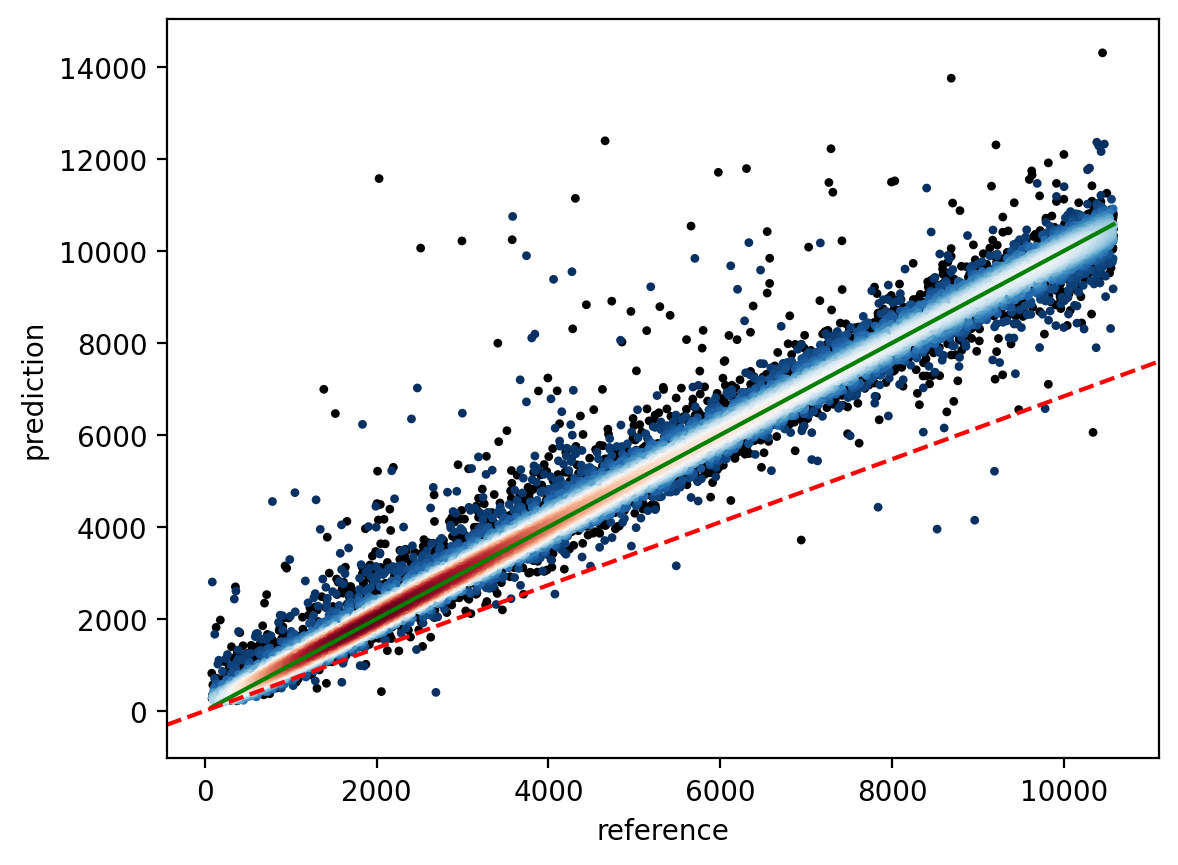

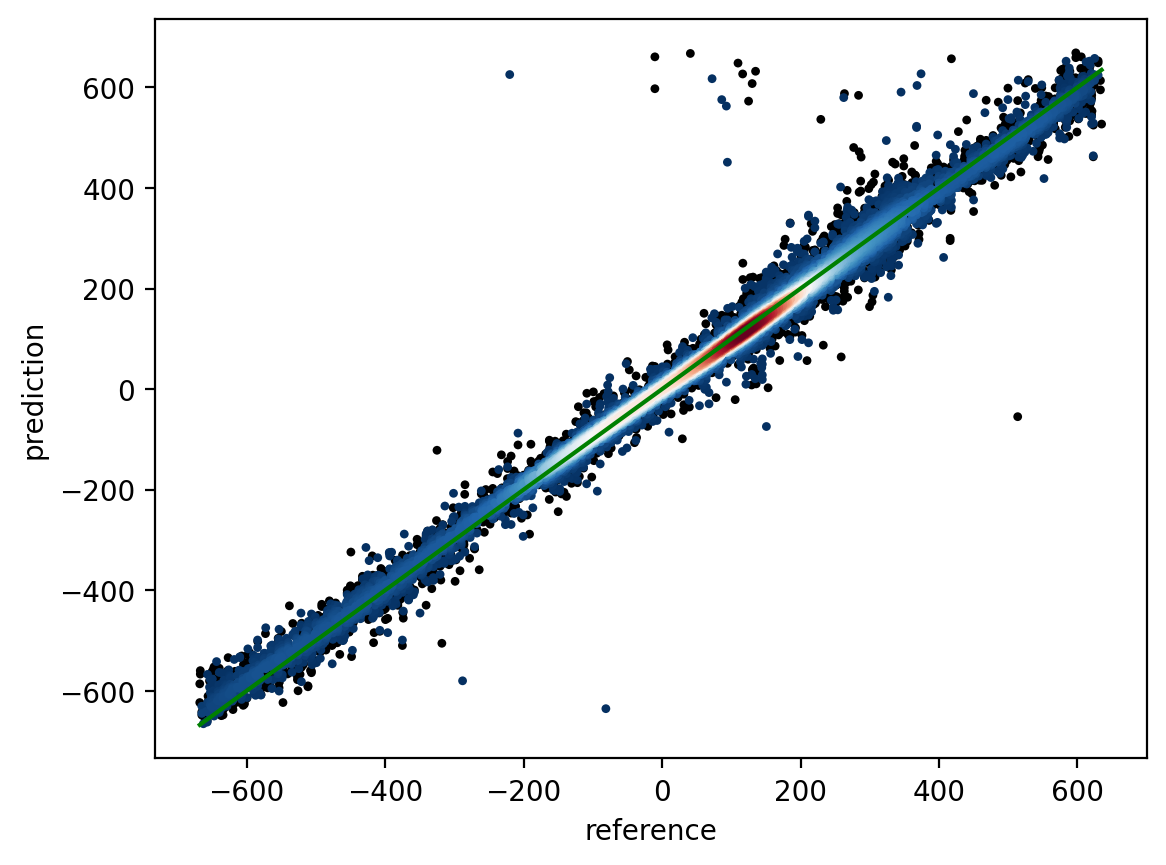

Text(0.5, 0, 'Target z [nm]')

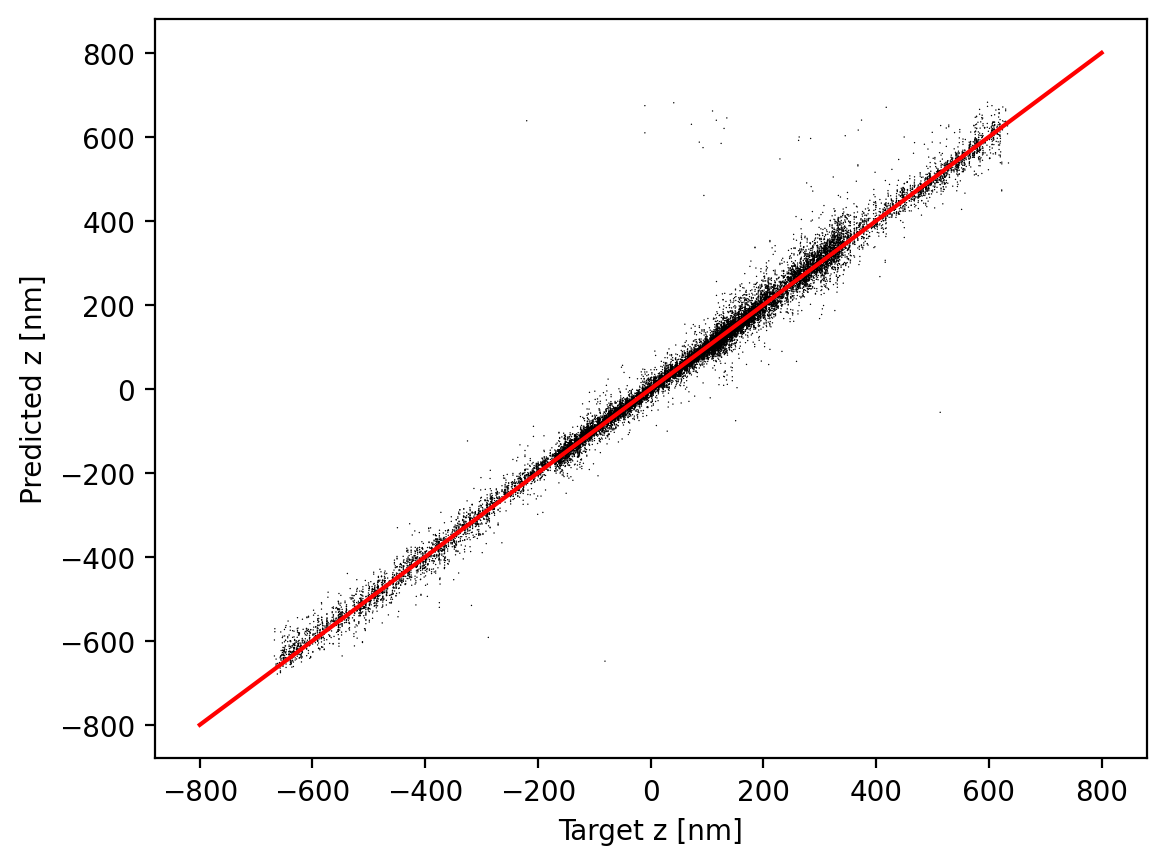

In [20]:
ix = 4
em_tar = matches.iloc[ix].tp_match
em_tar.bg = torch.ones_like(em_tar.phot)

em_out = matches.iloc[ix].tp

decode.evaluation.predict_dist.deviation_dist(em_out.phot, em_tar.phot)
# plt.scatter(em_tar.phot, em_out.phot.sum(1))

ax = plt.gca()

# # plot linear
xlim = ax.get_xlim()
x = torch.linspace(*xlim, 100)
# plt.plot(x, x, "k--")
plt.plot(x, x * 0.684, "r--")

ax.set_xlim(xlim)

plt.show()

decode.evaluation.predict_dist.deviation_dist(em_out.xyz_nm[:, 2] * 0.98, em_tar.xyz_nm[:, 2])
plt.show()

plt.scatter(em_tar.xyz_nm[:, 2], em_out.xyz_nm[:, 2], s=1, color="k", marker=".", facecolors="k", edgecolors="none")
xlim = [-800., 800]
x = torch.linspace(*xlim, 100)
plt.plot(x, x, "r-")
plt.ylabel("Predicted z [nm]")
plt.xlabel("Target z [nm]")

In [29]:
renderer = decode.renderer.renderer.Renderer2D(
    xextent=(0., 64*100.),
    yextent=(100., 64*100.),
    colextent=[-500,500],
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    contrast=10,
    cmap="turbo",
)

renderer_ax = decode.renderer.renderer.Renderer2D(
    xextent=(0., 64*100.),
    yextent=(100., 64*100.),
    colextent=[-500,500],
    px_size=10.,
    sigma_blur=10.,
    rel_clip=0.05,
    contrast=10,
    cmap="turbo",
    plot_axis=(0, 2)
)

In [52]:
radius = 70.
density_est = decode.emitter.density.NearestNeighborsDensity(radius=radius)


In [ ]:

for i, s in scen_filter.iterrows():
    if s.em is None:
        continue
    em_gt = s.em.clone()
    em_rend = s.em_out_filt.clone()

    xyz = em_rend.xyz_nm.clone()
    xyz[:, 2] /= 2
    density = density_est.fit(xyz)

    th_space = torch.arange(0, 40, 2)
    result = []

    metric = _ChallengeMetric(matcher, s.filter_phot, ev, filter_fov, None)
    metric._metric = None

    for threshold in tqdm(th_space, total=len(th_space)):
        em_rend_neg = em_rend[density <= threshold]
        em_rend_pos = em_rend[density > threshold]

        result.append(metric.forward(em_rend_pos, em_gt))

    result = pd.DataFrame(result)
    result["threshold"] = th_space
    result.set_index("threshold", inplace=True)

    fig, axs = plt.subplots(1, 3, figsize=(16, 6))
    result[["prec", "rec", "jac"]].plot(ax=axs[0])
    result[["effcy_lat", "effcy_ax", "effcy_vol"]].plot(ax=axs[1])
    result[["rmse_lat", "rmse_ax", "rmse_vol", "mad_lat", "mad_ax", "mad_vol"]].plot(ax=axs[2])
    plt.savefig(path_out / f"threshold_{'_'.join(i)}_{threshold}_radius-{radius}.png")


pos: 38932, neg: 2338


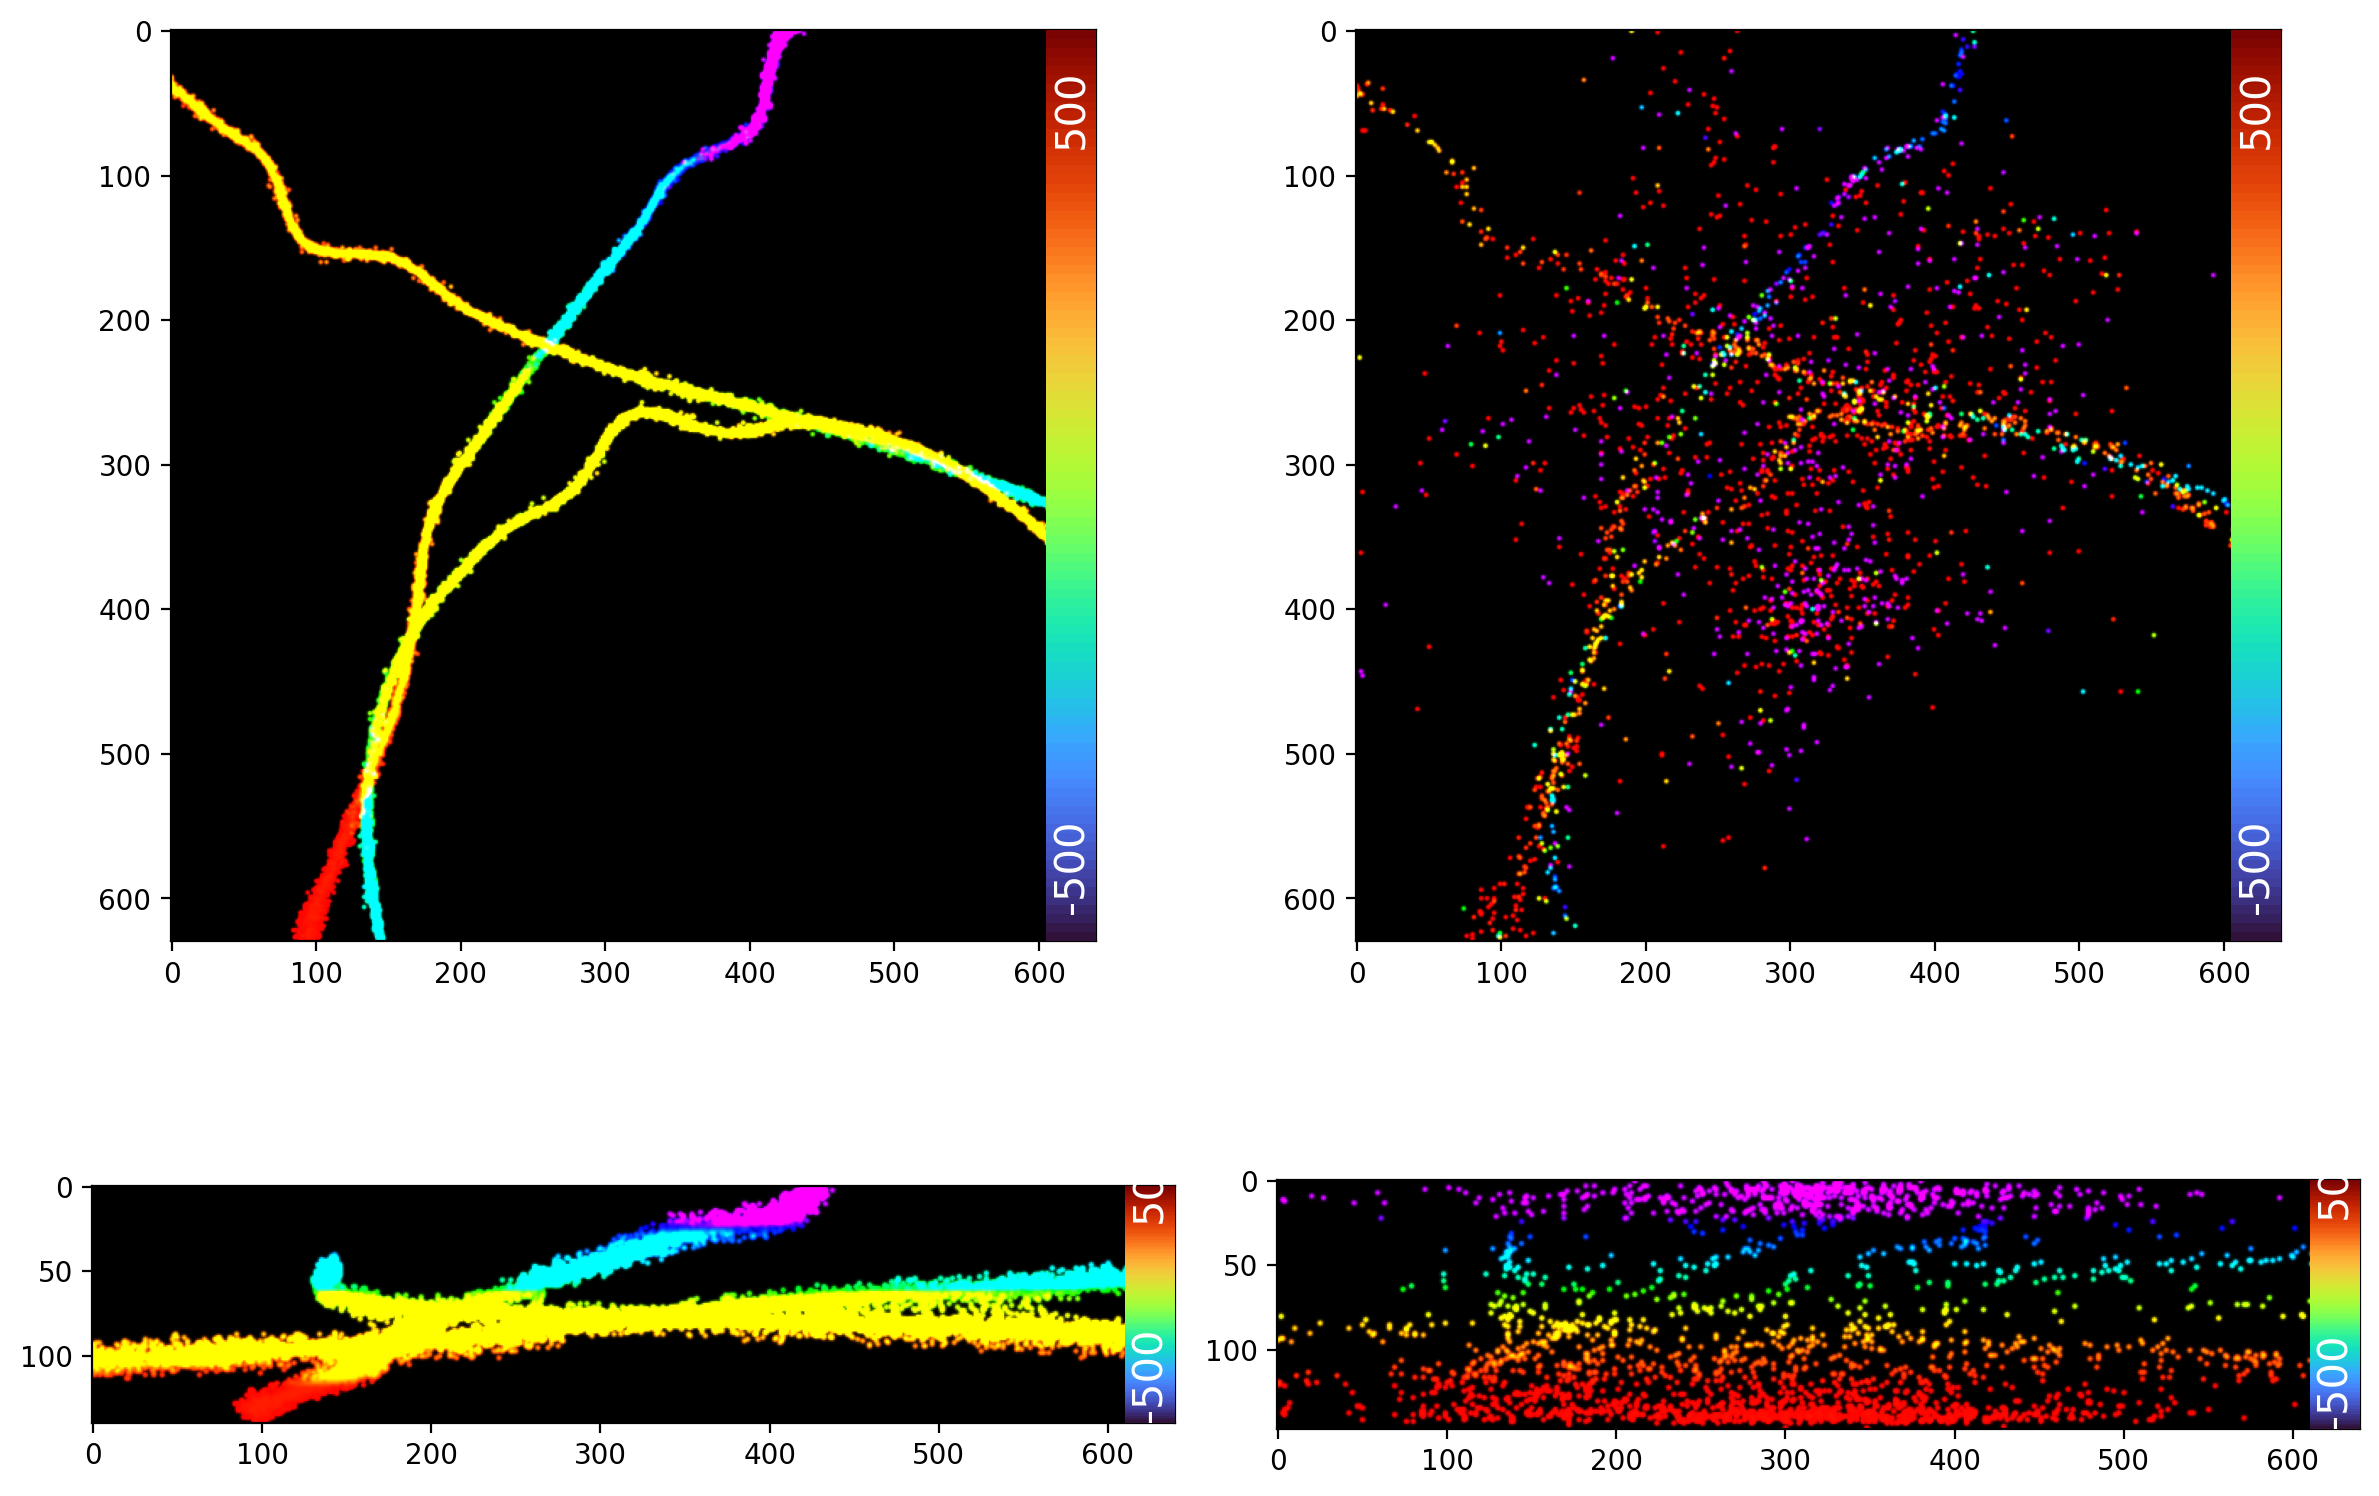

In [66]:
threshold = 10

em_rend = scen_filter.iloc[7].em_out_filt.clone()
density = density_est.fit(em_rend.xyz_nm)

em_rend_neg = em_rend[density <= threshold]
em_rend_pos = em_rend[density > threshold]

fig, axs = plt.subplots(2, 2, figsize=(12, 9))
renderer.render(em_rend_pos, em_rend_pos.xyz[:, 2], ax=axs[0, 0])
renderer.render(em_rend_neg, em_rend_neg.xyz[:, 2], ax=axs[0, 1])

renderer_ax.render(em_rend_pos, em_rend_pos.xyz[:, 2], ax=axs[1, 0])
renderer_ax.render(em_rend_neg, em_rend_neg.xyz[:, 2], ax=axs[1, 1])

plt.tight_layout()
# plt.imshow(img)
print(f"pos: {len(em_rend_pos)}, neg: {len(em_rend_neg)}")

In [54]:
scen_val = pd.DataFrame(index=scen.index)
scen_val["cfg"] = None
scen_val["phot_quantiles"] = None
scen_val["phot_max_valid"] = None
n_ch = 2
for j in range(n_ch):
    scen_val[f"bg_quantiles_{j}"] = None
    scen_val[f"bg_valid_{j}"] = None

for i, s in scen.join(scen_out).join(scen_filter[["em_out_filt"]]).iterrows():
    if s.path_model is None:
        continue

    # print(s.path_model)

    cfg = decode.io.param.load(s.path_model / "param_run.yaml")
    # scen_val.at[i, "cfg"] = cfg
    scale = cfg["Scaling"]["output"]
    scen_val.at[i, "phot_quantiles"] = s.em_out_filt.phot.max().item() # torch.quantile(, torch.tensor([0., 0.01, 0.99, 1.])).tolist()
    scen_val.at[i, "phot_max_valid"] = scale["phot"]["max"][0]
    bg_quant = torch.quantile(s.em_out_filt.bg, torch.tensor([0., 1.]), dim=0)
    for j in range(2):
        scen_val.at[i, f"bg_quantiles_{j}"] = bg_quant[:, j].tolist()
        scen_val.at[i, f"bg_valid_{j}"] = cfg["Simulation"]["bg"][j]["uniform"]

scen_val

cfg phot_quantiles phot_max_valid  \
snr  density type  algorithm                                       
low  low     train DECODE     None    1357.743286         1700.0   
             test  DECODE     None    1496.470337         1700.0   
     high    train DECODE     None    1498.892212         1700.0   
             test  DECODE     None    1610.283325         1700.0   
high low     train DECODE     None   14303.615234          17000   
             test  DECODE     None   14356.074219          17000   
     high    train DECODE     None   15954.896484          17000   
             test  DECODE     None   16948.810547          17000   

                                                       bg_quantiles_0  \
snr  density type  algorithm                                            
low  low     train DECODE     [9.980304718017578, 10.030024528503418]   
             test  DECODE     [9.983736038208008, 10.022125244140625]   
     high    train DECODE     [9.971896171569824, 10.027787208557129]   
             test  DECODE     [9.975954055786133, 10.030841827392578]   
high low     train DECODE     [99.73519134521484, 100.44029998779297]   
             test  DECODE     [102.5335464477539, 119.23258972167969]   
     high    train DECODE     [99.48283386230469, 100.39701843261719]   
             test  DECODE     [96.53585815429688, 127.29168701171875]   

                                 bg_valid_0  \
snr  density type  algorithm                  
low  low     train DECODE            [10.0]   
             test  DECODE            [10.0]   
     high    train DECODE            [10.0]   
             test  DECODE            [10.0]   
high low     train DECODE           [100.0]   
             test  DECODE     [50.0, 150.0]   
     high    train DECODE           [100.0]   
             test  DECODE     [50.0, 150.0]   

                                                       bg_quantiles_1  \
snr  density type  algorithm                                            
low  low     train DECODE     [9.941347122192383, 10.043169975280762]   
             test  DECODE     [9.970199584960938, 10.036624908447266]   
     high    train DECODE     [9.934216499328613, 10.042906761169434]   
             test  DECODE     [9.965747833251953, 10.046972274780273]   
high low     train DECODE     [99.55315399169922, 100.25498962402344]   
             test  DECODE     [101.57376098632812, 120.2873764038086]   
     high    train DECODE         [99.0322265625, 100.41266632080078]   
             test  DECODE      [99.44967651367188, 133.7126922607422]   

                                 bg_valid_1  
snr  density type  algorithm                 
low  low     train DECODE            [10.0]  
             test  DECODE            [10.0]  
     high    train DECODE            [10.0]  
             test  DECODE            [10.0]  
high low     train DECODE           [100.0]  
             test  DECODE     [50.0, 150.0]  
     high    train DECODE           [100.0]  
             test  DECODE     [50.0, 150.0]

In [60]:
scen_filter["density"] = 10.
scen_filter["em_dens_filt"] = None

for i, s in scen_filter.iterrows():
    if s.em_out_filt is None:
        continue

    em = s.em_out_filt.clone()
    xyz = em.xyz_nm.clone()
    xyz[:, 2] /= 2
    density = density_est.fit(xyz)

    em = em[density > s.density]
    scen_filter.at[i, "em_dens_filt"] = em

scen_filter

prob xyz_sig_lat_nm xyz_sig_ax_nm    metric  \
snr  density type  algorithm                                                
low  low     train DECODE      0.5           None          None -0.680127   
             test  DECODE      0.5           None          None      None   
     high    train DECODE      0.5           None          None -0.507411   
             test  DECODE      0.5           None          None      None   
high low     train DECODE      0.5           None          None -0.873564   
             test  DECODE      0.5           None          None      None   
     high    train DECODE      0.5           None          None  -0.64087   
             test  DECODE      0.5           None          None      None   

                             filter_phot  xyz_sig_vol_nm  \
snr  density type  algorithm                               
low  low     train DECODE          100.0       81.783719   
             test  DECODE          100.0       81.783719   
     high    train DECODE          100.0      111.928665   
             test  DECODE          100.0      111.928665   
high low     train DECODE         1000.0       59.669693   
             test  DECODE         1000.0       59.669693   
     high    train DECODE         1000.0      146.278306   
             test  DECODE         1000.0      146.278306   

                                                                             em  \
snr  density type  algorithm                                                      
low  low     train DECODE     EmitterSet
::num emitters: 24938
::xy unit: nm...   
             test  DECODE                                                  None   
     high    train DECODE     EmitterSet
::num emitters: 31612
::xy unit: nm...   
             test  DECODE                                                  None   
high low     train DECODE     EmitterSet
::num emitters: 24938
::xy unit: nm...   
             test  DECODE                                                  None   
     high    train DECODE     EmitterSet
::num emitters: 31612
::xy unit: nm...   
             test  DECODE                                                  None   

                                                                         em_out  \
snr  density type  algorithm                                                      
low  low     train DECODE     EmitterSet
::num emitters: 34258
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 20398
::xy unit: nm...   
     high    train DECODE     EmitterSet
::num emitters: 35255
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 38525
::xy unit: nm...   
high low     train DECODE     EmitterSet
::num emitters: 32439
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 29505
::xy unit: nm...   
     high    train DECODE     EmitterSet
::num emitters: 44545
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 48273
::xy unit: nm...   

                                                                    em_out_filt  \
snr  density type  algorithm                                                      
low  low     train DECODE     EmitterSet
::num emitters: 19850
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 18079
::xy unit: nm...   
     high    train DECODE     EmitterSet
::num emitters: 25711
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 32995
::xy unit: nm...   
high low     train DECODE     EmitterSet
::num emitters: 23014
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 22488
::xy unit: nm...   
     high    train DECODE     EmitterSet
::num emitters: 33317
::xy unit: nm...   
             test  DECODE     EmitterSet
::num emitters: 41270
::xy unit: nm...   

                              density  \
snr  density type  algorithm            
low  low     train DECODE        10.0   
             test  DECODE        10.0   
 

In [67]:
# save scen filter
scen_filter.to_pickle(path_out / "scen_filter.pkl")

for i, s in scen_filter.join(scen_out[["path_em_out"]]).iterrows():
    if s.em_out_filt is None:
        continue

    s.em_out.save(path_out / f"{s.path_em_out.stem}.h5")
    s.em_out_filt.save(path_out / f"{s.path_em_out.stem}_filtered.h5")
    s.em_dens_filt.save(path_out / f"{s.path_em_out.stem}_dens_filtered.h5")

s.path_em_out

PosixPath('/mnt/t1ries/users/Lucas/Manuscripts/plex/raw/biplane_challenge/MT2_N1_HD_decode_fit.h5')

In [82]:
scen_filter.iloc[7].em_out.xyz_sig_nm

tensor([[5.4417e-01, 4.6955e-01, 7.8922e+01],
        [8.5373e-01, 7.9157e-01, 1.0644e+02],
        [3.2356e-02, 2.9733e-02, 1.1802e+01],
        ...,
        [5.4462e-01, 5.6739e-01, 1.6812e+02],
        [6.0688e-01, 6.4110e-01, 8.4295e+01],
        [6.8294e-02, 6.5146e-02, 1.0686e+01]])